# MÉTODOS DE CLUSTERING

Prof. David Romo Bucheli, PhD

Semillero PredictPath 2026-2


# ¿Qué es clustering?

El `clustering` abarca técnicas de aprendizaje no supervisado diseñadas para identificar grupos o patrones dentro de un conjunto de datos, agrupando observaciones similares entre sí y diferentes de las de otros grupos. A diferencia de la clasificación, no utiliza etiquetas o información previa sobre las categorías de las observaciones durante su proceso. Esta característica lo distingue como un método exploratorio ideal para descubrir estructuras subyacentes en los datos.

Pueden diferenciarse estos tipos de clustering:

- Partitioning Clustering: este tipo de algoritmos requieren que el usuario especifique de antemano el número de clusters que se van a crear (K-means, K-medoids, ...).

-  Hierarchical Clustering: este tipo de algoritmos no requieren que el usuario especifique de antemano el número de clusters. (agglomerative clustering, divisive clustering).

Adicionalmente, tenemos algoritmos que están orientados a reducir la dimensionalidad de los datos, con el objetivo de encontrar también estructuras y agrupaciones en los datos. Estos, se encuentran enmarcados en un tipo de aprendizaje conocido como `manifold learning`.


## K-means

El algoritmo K-Means divide un conjunto de n muestras en k grupos, asignando cada punto al grupo cuyo centroide (media) esté más cerca, calculando la proximidad mediante la distancia euclidiana.


El algoritmo de k-means busca un número predefinido de clusters dentro de un conjunto de datos multidimensional no etiquetado. Esto se logra utilizando una concepción simple de cómo debería lucir una agrupación óptima:

- El "centro del cluster" es la media aritmética de todos los puntos que pertenecen a ese cluster.

- Cada punto está más cerca de su propio centro de cluster que de los centros de otros clusters.

Estas dos suposiciones son la base del modelo de k-means. Veamos como funcionan en un simple ejemplo:



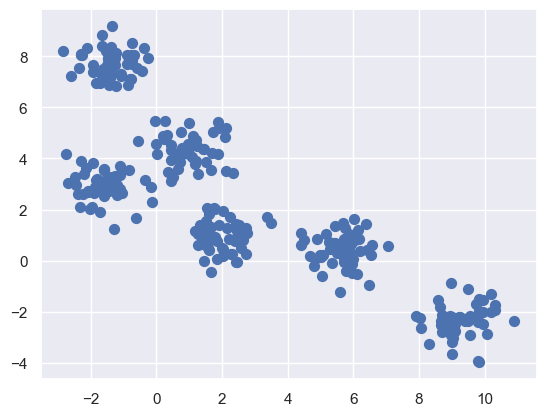

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=300, centers=6,
                       cluster_std=0.60, random_state=0)

plt.scatter(X[:, 0], X[:, 1], s=50);

A simple vista, es relativamente fácil identificar los cuatro clusters. El algoritmo de k-means realiza esta tarea automáticamente y, en Scikit-Learn, utiliza la típica API de estimadores para lograrlo:

In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Ahora visualicemos los resultados, graficando los datos coloreados por sus etiquetas. Graficaremos también los centros de los clusters determinados, por el estimador k-means:

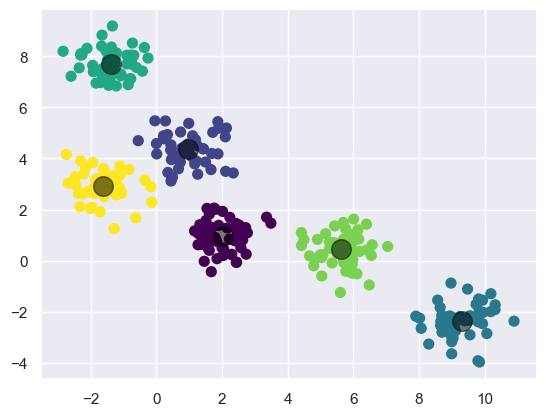

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);


La buena noticia es que el algoritmo de k-means (al menos en este caso simple) asigna los puntos a los clusters de una manera muy similar a cómo lo haríamos a simple vista. Sin embargo, podrías preguntarte cómo este algoritmo encuentra los clusters tan rápidamente. Después de todo, el número de combinaciones posibles de asignaciones de clusters crece exponencialmente con el número de puntos de datos, por lo que una búsqueda exhaustiva sería extremadamente costosa. Afortunadamente, no es necesario realizar una búsqueda exhaustiva: en su lugar, el enfoque típico de k-means utiliza un método iterativo e intuitivo conocido como expectation–maximization

### Algoritmo k-means: Maximización de la Esperanza

En el caso de k-means, El algoritmo *Expectation-Maximization (E-M)* es una aplicación simple de entender que sigue este procedimiento:

1. **Adivinar centros iniciales de los clusters.**

2. **Repetir hasta converger:**
   - **E-Step (Expectation):** Asignar cada punto al cluster cuyo centro esté más cercano.
   - **M-Step (Maximization):** Actualizar los centros de los clusters como la media de los puntos asignados.

El **E-step** actualiza la expectativa de pertenencia de cada punto a un cluster. Por otro lado, el **M-step** maximiza una función de ajuste para calcular las posiciones óptimas de los centros (en este caso, tomando la media simple). Resumiendo, bajo circunstancias típicas, cada iteración de los pasos E y M mejora progresivamente la estimación de las características de los clusters.


Una versión interactiva del proceso, la podemos ver a continuación:

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()  # for plot styling
import numpy as np

from ipywidgets import interact
from sklearn.metrics import pairwise_distances_argmin
from sklearn.datasets import make_blobs

def plot_kmeans_interactive(min_clusters=1, max_clusters=6):
    X, y = make_blobs(n_samples=300, centers=4,
                      random_state=0, cluster_std=0.60)
        
    def plot_points(X, labels, n_clusters):
        plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis',
                    vmin=0, vmax=n_clusters - 1);
            
    def plot_centers(centers):
        plt.scatter(centers[:, 0], centers[:, 1], marker='o',
                    c=np.arange(centers.shape[0]),
                    s=200, cmap='viridis')
        plt.scatter(centers[:, 0], centers[:, 1], marker='o',
                    c='black', s=50)
            

    def _kmeans_step(frame=0, n_clusters=4):
        rng = np.random.RandomState(2)
        labels = np.zeros(X.shape[0])
        centers = rng.randn(n_clusters, 2)

        nsteps = frame // 3

        for i in range(nsteps + 1):
            old_centers = centers
            if i < nsteps or frame % 3 > 0:
                labels = pairwise_distances_argmin(X, centers)

            if i < nsteps or frame % 3 > 1:
                centers = np.array([X[labels == j].mean(0)
                                    for j in range(n_clusters)])
                nans = np.isnan(centers)
                centers[nans] = old_centers[nans]

        # plot the data and cluster centers
        plot_points(X, labels, n_clusters)
        plot_centers(old_centers)

        # plot new centers if third frame
        if frame % 3 == 2:
            for i in range(n_clusters):
                plt.annotate('', centers[i], old_centers[i], 
                             arrowprops=dict(arrowstyle='->', linewidth=1))
            plot_centers(centers)

        plt.xlim(-4, 4)
        plt.ylim(-2, 10)

        if frame % 3 == 1:
            plt.text(3.8, 9.5, "1. Reassign points to nearest centroid",
                     ha='right', va='top', size=14)
        elif frame % 3 == 2:
            plt.text(3.8, 9.5, "2. Update centroids to cluster means",
                     ha='right', va='top', size=14)
    
    return interact(_kmeans_step, frame=(0, 50),
                    n_clusters=(min_clusters, max_clusters))

plot_kmeans_interactive();

interactive(children=(IntSlider(value=0, description='frame', max=50), IntSlider(value=4, description='n_clust…

### Consideraciones del Algoritmo Expectation-Maximization (E-M)

**Más allá de lo básico**
Las implementaciones bien probadas de E-M suelen incluir optimizaciones adicionales, pero el enfoque descrito anteriormente captura la esencia del método.

**Limitaciones del Algoritmo**
Aunque el algoritmo E-M tiene ventajas, es importante considerar algunas de sus limitaciones:

*No siempre alcanza el resultado global óptimo*

Aunque el procedimiento E-M mejora la solución en cada iteración, no garantiza encontrar la mejor solución global. Por ejemplo, un cambio en la semilla aleatoria de los centros iniciales puede conducir a resultados subóptimos debido a malas suposiciones iniciales.


Una implementación sencilla es lo siguiente. La mayoria de las implementaciones en librerias de aprendizaje máquina, realizan ajustes adicionales. Pero en general esta implementación da una buena idea del proceso:

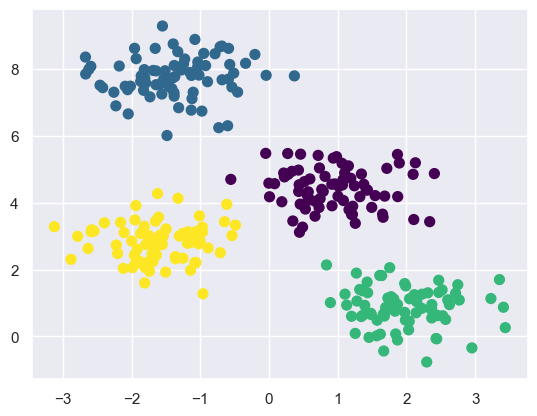

In [13]:
from sklearn.metrics import pairwise_distances_argmin

X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)

def find_clusters(X, n_clusters, rseed=2):
    # 1. Seleccion aleatoria de cluaters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]
    
    while True:
        # 2a. Asignar etiquetas basado en distancia más cercanas
        labels = pairwise_distances_argmin(X, centers)
        
        # 2b. Encuentra nuevos centro a partir de los puntos que pertenecen al grupo
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])
        
        # 2c. Revisar convergencia
        if np.all(centers == new_centers):
            break
        centers = new_centers
    
    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

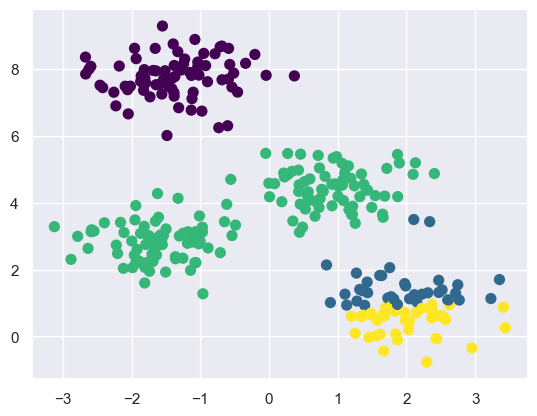

In [14]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

Aquí, el enfoque E-M ha convergido, pero no a una configuración globalmente óptima. Por esta razón, es común ejecutar el algoritmo con múltiples inicializaciones, como lo hace Scikit-Learn por defecto (controlado por el parámetro `n_init`, que por defecto está configurado en 10).

El número de clusters debe seleccionarse previamente.

Otro desafío común con k-means es que se debe especificar cuántos clusters se esperan; el algoritmo no puede determinar automáticamente este número a partir de los datos. Por ejemplo, si se le solicita identificar seis clusters, procederá a encontrar los mejores seis clusters, incluso si esa cantidad no refleja adecuadamente la estructura de los datos. Por ejemplo, el ejemplo anterior podemos adaptarlo para encontrar 6 clusters sin ningun problema.

Si el resultado es significativo o no es una pregunta difícil de responder de manera definitiva. Un enfoque intuitivo para abordar esta cuestión, aunque no lo discutiremos aquí, se llama análisis de silueta (*silhouette analysis*) [1]. Otro enfoque es el método del codo.

### Método del Codo (*Elbow Method*)
El Método del Codo consiste en graficar la suma de cuadrados dentro de los clusters (*Within-Cluster Sum of Squares*, WCSS) frente al número de clusters. El número óptimo de clusters se encuentra en el "punto de codo", donde la tasa de disminución del WCSS se reduce de manera notable.



C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set

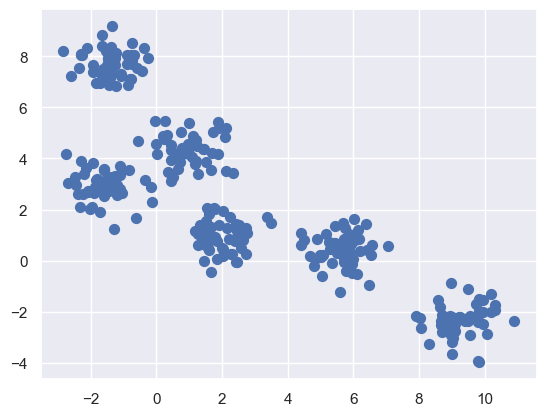

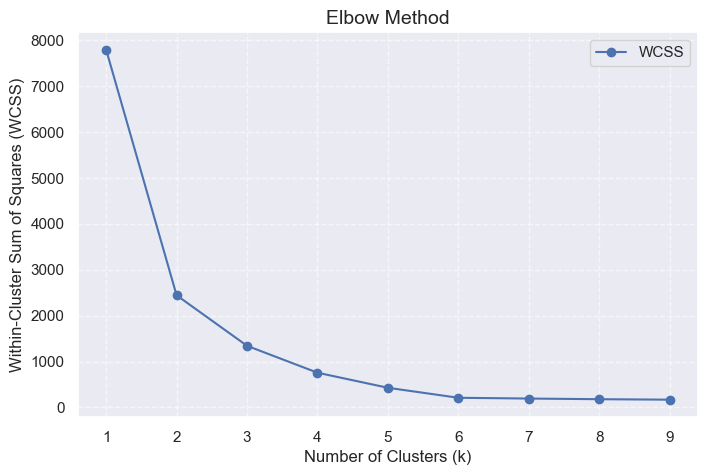

In [16]:
X, y_true = make_blobs(n_samples=300, centers=6,
                       cluster_std=0.60, random_state=0)

plt.scatter(X[:, 0], X[:, 1], s=50);

k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# Diccionario para almacenar los resultados de WCSS
wcss = {}

# Cálculo de K-Means y WCSS para cada valor de k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss[k] = kmeans.inertia_  # La inercia es el WCSS


# Graficamos el Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, list(wcss.values()), marker='o', linestyle='-', label='WCSS')
plt.title('Elbow Method', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Spectral clustering

El modelo fundamental de k-means asume que los puntos estarán más cerca del centro de su propio cluster que de los demás. Esto implica que el algoritmo suele ser ineficaz si los clusters tienen geometrías complicadas.

En particular, las fronteras entre los clusters generados por k-means siempre serán lineales, lo que significa que el algoritmo no funcionará bien para límites más complejos. Por ejemplo, considere un conjunto de datos con geometrías no lineales y las etiquetas de clusters generadas por el enfoque típico de k-means.

C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


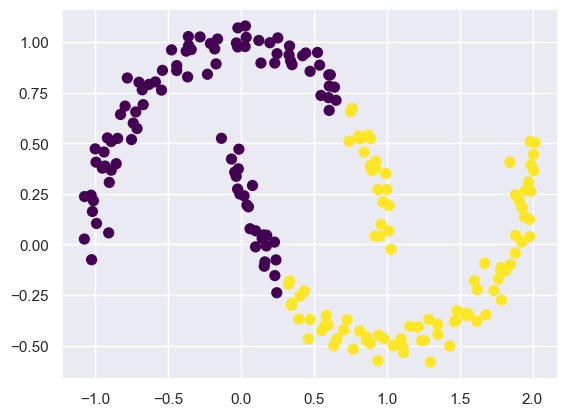

In [17]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

Podemos usar lo que se denomina una transformación de kernel para proyectar los datos en una dimension superior en la cual una separación lineal es posible. Mediante Spectral Clustering es posible realizar este proceso. El grafo de los vecinos más cercanos es usado para calcular una representación en alta dimensionalidad de los datos, y después se asignan etiquetas usando el algoritmo k-means:

C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


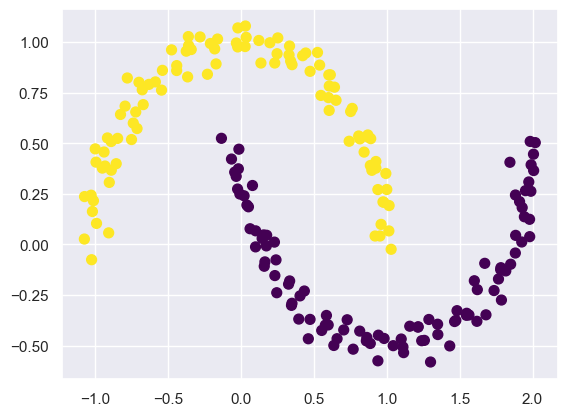

In [18]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

Podemos observar que, al aplicar este enfoque de transformación con kernel, el **k-means kernelizado** es capaz de identificar límites no lineales más complejos entre los clusters. Para más información, puede consultar [Python handbook for data science](https://jakevdp.github.io/PythonDataScienceHandbook/).

## Agrupamiento Jerárquico Aglomerativo

El **agrupamiento jerárquico** es una familia de algoritmos que construyen clusters anidados mediante fusiones o divisiones sucesivas, representados como un árbol (o dendrograma). La raíz del árbol representa un único cluster con todas las muestras, mientras que las hojas corresponden a clusters individuales.

### Clustering Aglomerativo
Este algoritmo realiza un agrupamiento jerárquico de abajo hacia arriba: cada observación comienza en su propio cluster y los clusters se fusionan sucesivamente. La estrategia de fusión depende del criterio de enlace:

- **Ward**: Minimiza la suma de las diferencias cuadráticas dentro de los clusters (similar al objetivo de k-means, pero jerárquico).
$$\frac{|A| \cdot|B|}{|A \cup B|}\left\|\mu_A-\mu_B\right\|^2=\sum_{x \in A \cup B}\left\|x-\mu_{A \cup B}\right\|^2-\sum_{x \in A}\left\|x-\mu_A\right\|^2-\sum_{x \in B}\left\|x-\mu_B\right\|^2$$

- **Enlace Máximo o Completo**: Minimiza la distancia máxima entre observaciones de pares de clusters.
$$\max _{a \in A, b \in B} d(a, b)$$
 
- **Enlace Promedio**: Minimiza el promedio de las distancias entre todas las observaciones de pares de clusters.
$$\frac{1}{|A| \cdot|B|} \sum_{a \in A} \sum_{b \in B} d(a, b)$$

- **Enlace Simple**: Minimiza la distancia entre las observaciones más cercanas de pares de clusters.
$$\min _{a \in A, b \in B} d(a, b)$$

El **Clustering Aglomerativo** puede manejar grandes cantidades de datos si se utiliza junto con una matriz de conectividad, pero resulta computacionalmente costoso cuando no hay restricciones de conectividad, ya que evalúa todas las fusiones posibles en cada paso.





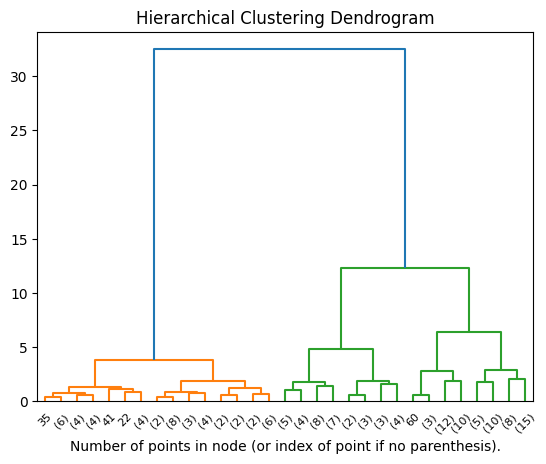

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


iris = load_iris()
X = iris.data

# Con distance_threshold=0 se calcula el arbol completo. Se utiliza por defecto el criterio de enlace Ward
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=4)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

[[101 142]
 [  7  39]
 [  0  17]
 [  9  34]
 [128 132]
 [ 10  48]
 [  4  37]
 [ 19  21]
 [ 29  30]
 [ 57  93]
 [ 80  81]
 [116 137]
 [  8  38]
 [  3  47]
 [ 27  28]
 [ 82  92]
 [ 95  96]
 [127 138]
 [  1  45]
 [ 63  91]
 [ 65  75]
 [ 40 152]
 [123 126]
 [ 49 151]
 [112 139]
 [ 94  99]
 [ 12 168]
 [ 88 166]
 [ 66  84]
 [ 23  26]
 [ 53  89]
 [ 74  97]
 [ 25 153]
 [ 46 157]
 [  2 163]
 [110 147]
 [120 143]
 [136 148]
 [ 78 169]
 [ 69 160]
 [ 54  58]
 [140 144]
 [141 145]
 [ 43 179]
 [ 68  87]
 [ 50  52]
 [ 51  56]
 [107 130]
 [105 122]
 [103 161]
 [164 171]
 [ 20  31]
 [ 11 158]
 [ 67 165]
 [ 70 167]
 [ 42 162]
 [113 150]
 [  6 184]
 [173 200]
 [ 55  90]
 [176 182]
 [ 86 195]
 [124 186]
 [ 83 133]
 [  5  18]
 [ 13 205]
 [175 177]
 [ 32  33]
 [125 129]
 [104 154]
 [ 73 188]
 [149 204]
 [146 172]
 [121 206]
 [ 36 155]
 [ 76 190]
 [115 187]
 [ 61  71]
 [156 208]
 [ 72 213]
 [117 131]
 [191 212]
 [ 24 202]
 [ 98 159]
 [ 16 224]
 [ 35 210]
 [ 64  79]
 [ 85 196]
 [ 77 185]
 [ 44 183]
 [111 199]

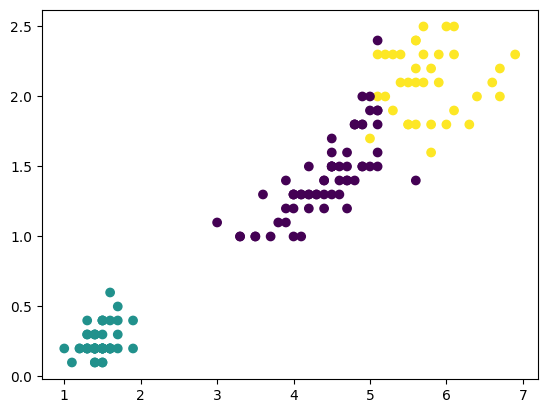

In [25]:
model = AgglomerativeClustering(n_clusters=3)
model = model.fit(X)

model.labels_

print(model.children_)

plt.scatter(X[:,2], X[:,3],c=model.labels_)


## Gaussian Mixture Models

**K-means**, es simple y fácil de entender. Pero su simplicidad genera desafíos prácticos en su aplicación. En particular, su naturaleza no probabilística y el uso de distancias simples desde el centro del cluster para asignar membresías pueden resultar en un rendimiento deficiente en muchas situaciones.

En esta sección, exploraremos los **modelos de mezcla gaussiana (GMMs)**, que extienden las ideas detrás de k-means y se presentan como una herramienta poderosa tanto para el agrupamiento como para la estimación en escenarios más complejos que incorporan ideas probabilisticas.

Desde un punto de vista intuitivo, podríamos esperar que la asignación de clusters para algunos puntos sea más segura que para otros. Por ejemplo, podría haber una ligera superposición entre dos clusters adyacentes, lo que genera incertidumbre en la asignación de puntos entre ellos. Sin embargo, el modelo de k-means no incluye una medida intrínseca de probabilidad o incertidumbre en las asignaciones de clusters. 

Una forma de interpretar el modelo de k-means es imaginar que coloca un círculo (o un hiperesfera en dimensiones superiores) en el centro de cada cluster, con un radio definido por el punto más distante dentro del cluster. Este radio funciona como un límite rígido para la asignación de clusters en el conjunto de entrenamiento: cualquier punto fuera de este círculo no se considera miembro del cluster. Visualicemos esto:


C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


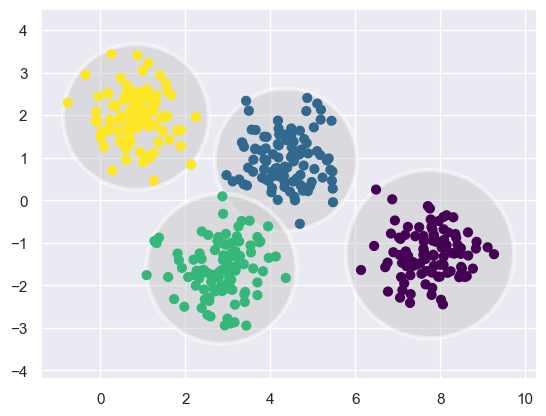

In [41]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist


X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1] # flip axes for better plotting

def plot_kmeans(kmeans, X, n_clusters=4, rseed=0, ax=None):
    labels = kmeans.fit_predict(X)

    # plot the input data
    ax = ax or plt.gca()
    ax.axis('equal')
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)

    # plot the representation of the KMeans model
    centers = kmeans.cluster_centers_
    radii = [cdist(X[labels == i], [center]).max()
             for i, center in enumerate(centers)]
    for c, r in zip(centers, radii):
        ax.add_patch(plt.Circle(c, r, fc='#CCCCCC', lw=3, alpha=0.5, zorder=1))



kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X)



Una observación importante sobre k-means es que los modelos de clusters deben ser circulares, ya que k-means no tiene un mecanismo incorporado para manejar clusters alargados u ovalados. Por ejemplo, si tomamos los mismos datos y los transformamos, las asignaciones de clusters pueden volverse confusas:


C:\Users\daedr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


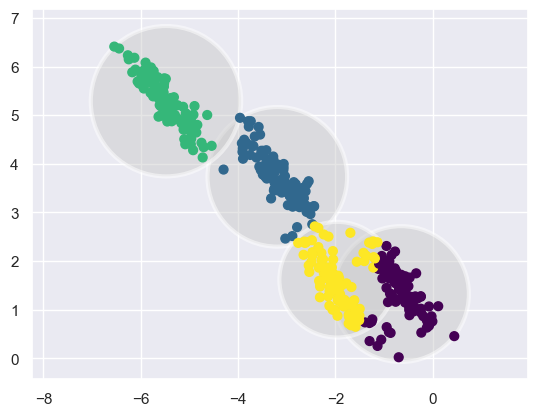

In [ ]:
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X_stretched)

K-means tiene limitaciones importantes cuando los clusters no son circulares, ya que intenta ajustar los datos a clusters circulares, lo que puede generar asignaciones confusas en áreas donde los círculos se solapan. Además, k-means carece de flexibilidad en la forma de los clusters y no incluye una asignación probabilística que permita medir la incertidumbre. 

Estas limitaciones pueden abordarse generalizando el modelo, por ejemplo, considerando las distancias de un punto a todos los centros de los clusters en lugar de solo al más cercano, o permitiendo que los límites de los clusters sean elípticos en lugar de circulares. Estas características son fundamentales en los modelos de mezcla gaussiana (GMMs), una alternativa más versátil y precisa a k-means.


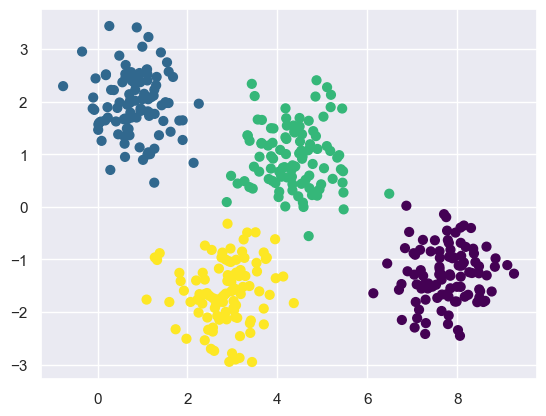

In [45]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4).fit(X)
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis');

Sin embargo, dado que los GMM incluyen un modelo probabilístico subyacente, también es posible obtener asignaciones probabilísticas de clusters. En Scikit-Learn, esto se realiza mediante el método `predict_proba`, que devuelve una matriz de tamaño \([n\_samples, n\_clusters]\) que mide la probabilidad de que cada punto pertenezca a un cluster específico.


In [46]:
probs = gmm.predict_proba(X)
print(probs[:5].round(3))

[[0.463 0.    0.537 0.   ]
 [0.    0.    0.    1.   ]
 [0.    0.    0.    1.   ]
 [0.    0.    1.    0.   ]
 [0.    0.    0.    1.   ]]


Podemos visualizar esta incertidumbre haciendo, por ejemplo, que el tamaño de cada punto sea proporcional a la certeza de su predicción. En la figura correspondiente, se observa que son precisamente los puntos en los límites entre clusters los que reflejan mayor incertidumbre en la asignación de clusters.


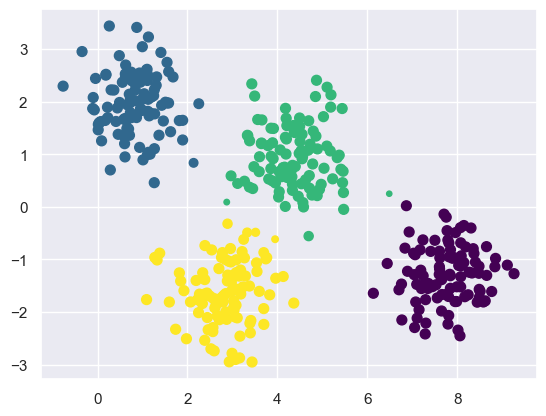

In [47]:


size = 50 * probs.max(1) ** 2  # square emphasizes differences
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=size);



Internamente, un modelo de mezcla gaussiana (GMM) es muy similar a k-means: utiliza un enfoque de **expectation–maximization (E-M)** que, cualitativamente, sigue estos pasos:

1. **Elegir suposiciones iniciales** para la ubicación y forma de los clusters.

2. **Repetir hasta converger**:
   - **E-step**: Para cada punto, calcular pesos que codifiquen la probabilidad de pertenencia a cada cluster.
   - **M-step**: Para cada cluster, actualizar su ubicación, normalización y forma utilizando todos los puntos de datos y teniendo en cuenta los pesos calculados.

El resultado es que cada cluster no está asociado a una esfera rígida, sino a un modelo Gaussiano suave. Al igual que en el enfoque de k-means, este algoritmo puede no encontrar siempre la solución globalmente óptima. Por esta razón, en la práctica se utilizan múltiples inicializaciones aleatorias.

A continuación, crearemos una función para visualizar las ubicaciones y formas de los clusters generados por el GMM, dibujando elipses basadas en la salida del modelo.


In [60]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height, angle=angle, **kwargs))
        
def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w * w_factor)

Ahora podemos visualizar las 4 componentes del modelo guasiano sobre nuestros datos:

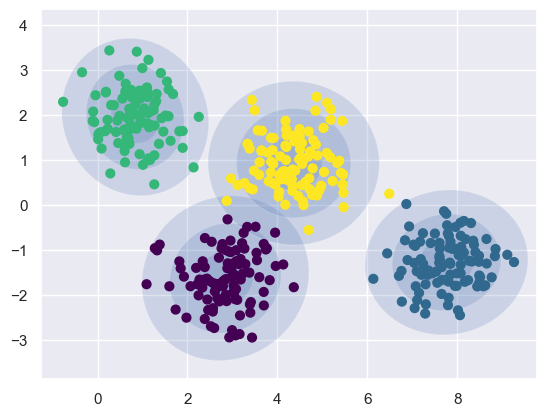

In [61]:
gmm = GaussianMixture(n_components=4, random_state=42)

plot_gmm(gmm, X)

De manera similar, podemos usar el enfoque de GMM para ajustar nuestro conjunto de datos alargado; al permitir una covarianza completa, el modelo será capaz de ajustarse incluso a clusters muy alargados y extendidos.

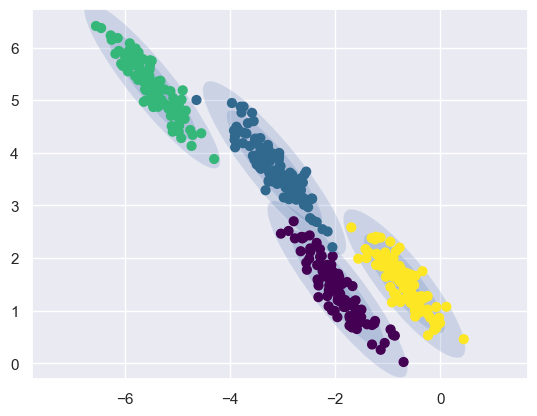

In [63]:
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
plot_gmm(gmm, X_stretched)

Así podemos observar que GMM nos permite abordar las limitaciones de k-means. El tipo de covarianza, puede ser completo, esferico o diagonal. El completo es más costoso computacionalmente. Los otros dos restringen la capacidad de GMM para adaptar los ejes de la elipse

![GMM tipos de covarianza](images/GMM_covar_type.png)

### ¿Cuantos componentes?

El hecho de que GMM sea un modelo generativo nos proporciona un medio natural para determinar el número óptimo de componentes en un conjunto de datos. Un modelo generativo es, inherentemente, una distribución de probabilidad para el dataset, por lo que podemos evaluar simplemente la probabilidad de los datos bajo el modelo, utilizando validación cruzada para evitar sobreajuste. 

Otra forma de corregir el sobreajuste es ajustar las probabilidades del modelo mediante criterios analíticos como el **criterio de información de Akaike (AIC)** o el **criterio de información bayesiano (BIC)**.  El estimador GMM de Scikit-Learn incluye métodos integrados para calcular ambos criterios, lo que facilita mucho este enfoque.

Veamos cómo se comportan el AIC y el BIC en función del número de componentes de GMM para nuestro conjunto de datos de luna.

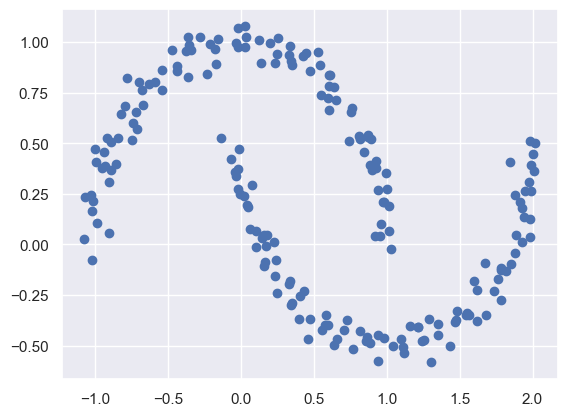

In [75]:
from sklearn.datasets import make_moons
Xmoon, ymoon = make_moons(200, noise=.05, random_state=0)
plt.scatter(Xmoon[:, 0], Xmoon[:, 1]);


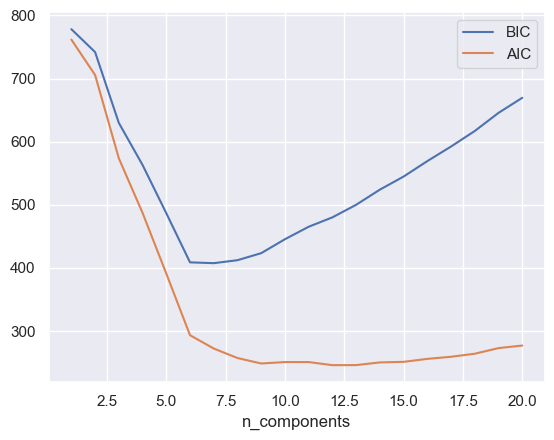

In [76]:

n_components = np.arange(1, 21)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(Xmoon)
          for n in n_components]

plt.plot(n_components, [m.bic(Xmoon) for m in models], label='BIC')
plt.plot(n_components, [m.aic(Xmoon) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

Es importante destacar que la elección del número de componentes mide qué tan bien funciona GMM como un estimador de densidad, no como un algoritmo de clustering. Es recomendable pensar en GMM principalmente como un estimador de densidad y usarlo para clustering solo cuando sea apropiado en conjuntos de datos simples.

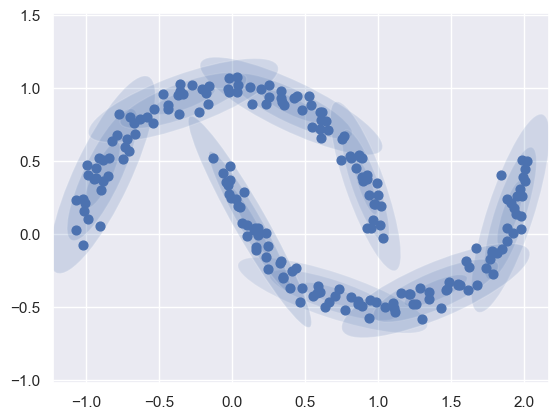

In [77]:
gmm8 = GaussianMixture(n_components=8, covariance_type='full', random_state=0)
plot_gmm(gmm8, Xmoon, label=False)

### Ejemplo adicional: Usando GMM como modelo generativo de nuevos datos

Acabamos de ver un ejemplo sencillo de cómo utilizar GMM como un modelo generativo de datos para crear nuevas muestras a partir de la distribución definida por los datos de entrada. Ahora exploraremos esta idea generando nuevos dígitos escritos a mano a partir del corpus estándar de dígitos que hemos usado anteriormente.

Para comenzar, carguemos los datos de dígitos utilizando las herramientas de datos de Scikit-Learn:


In [78]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

Veamos como se ven algunos de estos digitos:


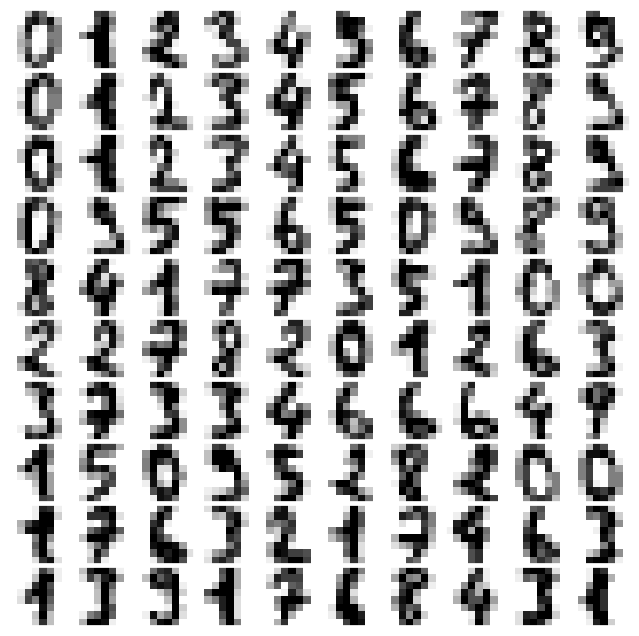

In [79]:
def plot_digits(data):
    fig, ax = plt.subplots(10, 10, figsize=(8, 8),
                           subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i].reshape(8, 8), cmap='binary')
        im.set_clim(0, 16)
plot_digits(digits.data)

Tenemos cerca de 1,800 dígitos representados en 64 dimensiones, y podemos construir un GMM sobre estos para generar más. Sin embargo, los GMM pueden tener dificultades para converger en espacios de alta dimensionalidad, por lo que comenzaremos aplicando un algoritmo de reducción de dimensionalidad que sea reversible. Aquí utilizaremos un PCA simple, configurado para preservar el 99% de la varianza en los datos proyectados:

In [80]:
from sklearn.decomposition import PCA
pca = PCA(0.99, whiten=True)
data = pca.fit_transform(digits.data)
data.shape

(1797, 41)

El resultado es una reducción a 41 dimensiones, lo que representa casi 1/3 menos de dimensiones con prácticamente ninguna pérdida de información. Con estos datos proyectados, utilizaremos el criterio AIC para estimar el número óptimo de componentes del GMM que deberíamos usar:


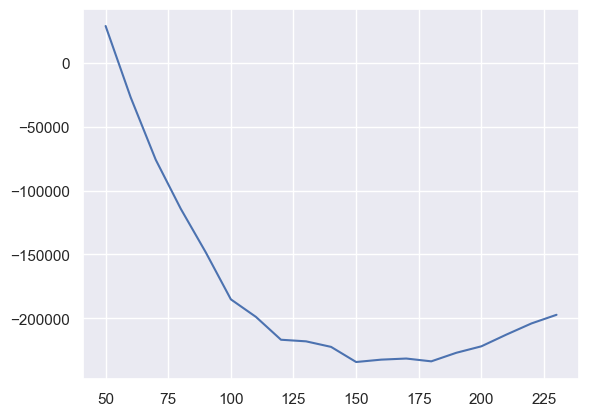

In [83]:
n_components = np.arange(50, 240, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=0)
          for n in n_components]
aics = [model.fit(data).aic(data) for model in models]
plt.plot(n_components, aics);

Con 150 componentes parece haber una buena minimización del AIC. Ajustemos las datos y evaluemos la convergencia:

In [85]:
gmm = GaussianMixture(110, covariance_type='full', random_state=0)
gmm.fit(data)
print(gmm.converged_)

True


Ahora podemos obtener muestras a partir de nuestro modelo!!

In [89]:
data_new = gmm.sample(100)
data_new[0].shape

(100, 41)

Aplicamos la transformada inversa PCA para visualizar los digitos muestreados:

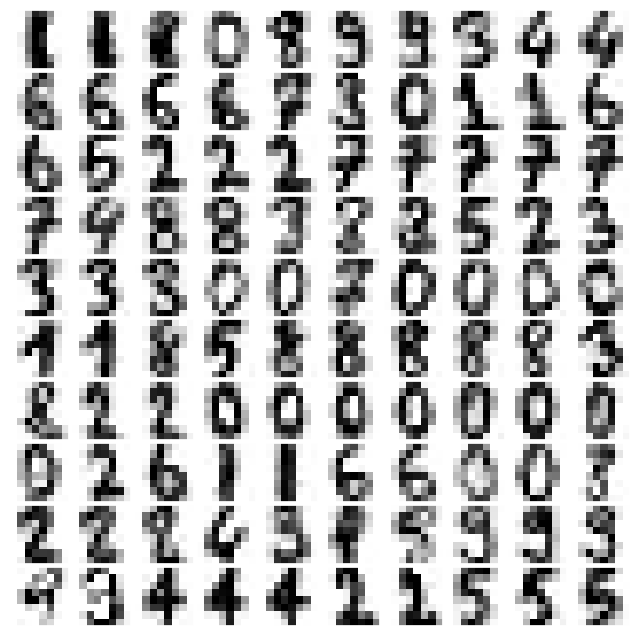

In [92]:
digits_new = pca.inverse_transform(data_new[0])
plot_digits(digits_new)

¡Los resultados, en su mayoría, se asemejan a dígitos plausibles del conjunto de datos original!

Consideremos lo que hemos logrado: a partir de una muestra de dígitos escritos a mano, hemos modelado la distribución de esos datos de manera que podemos generar nuevas muestras de dígitos. Estos son "dígitos escritos a mano" que no aparecen en el dataset original


# Actividad: Exploración de Datos y Clustering con Juego de Roles

Esta actividad es para realizar en grupos de tres personas. Usando uno de los datasets proporcionados en la última clase, el objetivo es aplicar los algoritmos de clustering vistos hoy y que realicen un análisis comparativo de los resultados obtenidos.

Cada miembro del equipo asumirá uno de los siguientes roles:

**Relator**: Lidera la discusión grupal, asegura que todos participen y documenta las decisiones, análisis y conclusiones. También será responsable de redactar un informe final.

**Investigador**: Formula preguntas relevantes sobre los datos y propone estrategias para aplicar los algoritmos de clustering.

**Analista de Datos**: Implementa los algoritmos de clustering (**k-means**, **clustering jerárquico aglomerativo** y **modelo de mezcla gaussiana**) y genera las visualizaciones necesarias para responder las preguntas planteadas.

## Tareas

### 1. Familiarización con el Dataset
- Exploren las columnas y características del dataset asignado.
- Identifiquen patrones iniciales, posibles outliers o relaciones interesantes entre variables.

### 2. Formulación de Preguntas
- El **Investigador** planteará preguntas que puedan responderse mediante clustering, como:
  - ¿Cuántos grupos naturales existen en los datos?
  - ¿Cómo varían los grupos según las variables principales?
  - ¿Qué similitudes y diferencias presentan los clusters obtenidos con distintos algoritmos?

### 3. Aplicación de Algoritmos de Clustering
- El **Analista de Datos** aplicará los algoritmos vistos hoy: **K-Means**, **Clustering Jerárquico Aglomerativo**, y **Modelo de Mezcla Gaussiana (GMM)**

- Se deben generar visualizaciones y métricas para interpretar los resultados (por ejemplo, gráficos de dispersión, dendrogramas o probabilidades de pertenencia).

### 4. Análisis Comparativo
- Comparen los resultados obtenidos con los tres métodos, destacando:
  - Similitudes y diferencias en la formación de clusters.
  - Ventajas y desventajas de cada método en este contexto.
  - Limitaciones observadas en los algoritmos según los datos asignados.

### 5. Conclusión y Discusión
- El **Relator** liderará una discusión grupal para sintetizar los hallazgos.
- Redactarán un breve informe que incluya:
  - Las preguntas planteadas.
  - Resultados y visualizaciones de los tres métodos.
  - Análisis comparativo de los algoritmos.
  - Conclusiones generales sobre el dataset y las herramientas utilizadas.

## Entregables
1. **Informe Final** Notebook documentando el desarrollo: Debe contener las preguntas formuladas, los resultados obtenidos, visualizaciones clave y el análisis comparativo. No olvidar incluir los integrantes del grupo

2. **Presentación Oral** (5 minutos por equipo): Cada equipo presentará un resumen de su análisis, destacando una comparación entre los algoritmos y las conclusiones principales.


¡Buena suerte y disfruten la exploración de los datos! 🚀


# REFERENCIAS

[1] [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)

[2] [Clustering - Scikit learn](https://scikit-learn.org/stable/modules/clustering.html)

[3] [Clustering con Python](https://cienciadedatos.net/documentos/py20-clustering-con-python) 

[4] [Teoria clustering](https://digibug.ugr.es/bitstream/handle/10481/85862/CA_en.pdf?sequence=1)

[5] [Silouette Analysis Paper](https://www.sciencedirect.com/science/article/pii/0377042787901257?via%3Dihub)